## RAG Pipeline: Data Ingestion to Vector DB Pipeline

In [20]:
import os
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path

In [21]:
### Reading all the PDF's inside the directory
def process_all_pdfs(pdf_directory):
    """Process all PDF files present in a directory"""
    all_documents = []
    pdf_dir = Path(pdf_directory)
    
    # Find all PDF files recursively
    pdf_files = list(pdf_dir.glob("**/*.pdf"))
    
    print(f"Found {len(pdf_files)} PDF files to process")
    
    for pdf_file in pdf_files:
        print(f"\nProcessing: {pdf_file.name}")
        try:
            loader = PyPDFLoader(str(pdf_file))
            documents = loader.load()
            
            # Adding more information to metadata
            for doc in documents:
                doc.metadata['source_file'] = pdf_file.name
                doc.metadata['file_type'] = 'pdf'
            
            all_documents.extend(documents)
            print(f"  ✓ Loaded {len(documents)} pages")
            
        except Exception as e:
            print(f"  ✗ Error: {e}")
    
    print(f"\nTotal documents loaded: {len(all_documents)}")
    return all_documents

# Process all PDF's in the data folder
all_pdf_documents = process_all_pdfs("../data")

Found 2 PDF files to process

Processing: pdf1.pdf
  ✓ Loaded 11 pages

Processing: pdf2.pdf
  ✓ Loaded 6 pages

Total documents loaded: 17


In [22]:
all_pdf_documents

[Document(metadata={'producer': 'GPL Ghostscript 8.15', 'creator': 'PageMaker 7.0', 'creationdate': '2017-12-22T16:44:03+00:00', 'author': 'NCERT', 'moddate': '2026-03-27T12:35:42+05:30', 'title': 'chap-01.pmd', 'source': '..\\data\\pdf_files\\pdf1.pdf', 'total_pages': 11, 'page': 0, 'page_label': '1', 'source_file': 'pdf1.pdf', 'file_type': 'pdf'}, page_content='1/I SELL MY DREAMS\nShort stories\nINTRODUCTION\nA short story is a prose narrative of limited length.\nIt organises the action and thoughts of its\ncharacters into the pattern of a plot. The plot\nform may be comic, tragic, romantic or satiric.\nThe central incident is selected to manifest, as\nmuch as possible, the protagonist’s life and\ncharacter , and the details contribute to the\ndevelopment of the plot.\nThe term ‘short story’ covers a great diversity of\nprose fiction, right from the really short ‘short\nstory’ of about five hundred words to longer and\nmore complex works. The longer ones, with their\nstatus of middle

In [23]:
### Text splitting get into chunks
def split_documents(documents, chunk_size=1000, chunk_overlap=200) :
#chunk overlap: repeating a small portion of text from the end of one chunk at the beginning of the next(in characters)
    """Split documents into smaller chunks for better RAG performance"""
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )
    split_docs = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")
    
    # Show example of a chunk
    if split_docs:
        print(f"\nExample chunk:")
        print(f"Content: {split_docs[0].page_content[:200]}...")
        print(f"Metadata: {split_docs[0].metadata}")
    
    return split_docs

In [24]:
chunks=split_documents(all_pdf_documents)

Split 17 documents into 42 chunks

Example chunk:
Content: 1/I SELL MY DREAMS
Short stories
INTRODUCTION
A short story is a prose narrative of limited length.
It organises the action and thoughts of its
characters into the pattern of a plot. The plot
form may...
Metadata: {'producer': 'GPL Ghostscript 8.15', 'creator': 'PageMaker 7.0', 'creationdate': '2017-12-22T16:44:03+00:00', 'author': 'NCERT', 'moddate': '2026-03-27T12:35:42+05:30', 'title': 'chap-01.pmd', 'source': '..\\data\\pdf_files\\pdf1.pdf', 'total_pages': 11, 'page': 0, 'page_label': '1', 'source_file': 'pdf1.pdf', 'file_type': 'pdf'}


### Embedding and VectorStore DB

In [25]:
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
import uuid
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity

In [26]:
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
import uuid
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity
import os
from typing import List, Any

In [27]:
class EmbeddingManager:
    """Handles document embedding generation using SentenceTransformer"""
    
    def __init__(self, model_name: str = "all-MiniLM-L6-v2"): #Hugging Face Model
        """
        Initialize the embedding manager
        
        Args:
            model_name: HuggingFace model name for sentence embeddings
        """
        self.model_name = model_name
        self.model = None
        self._load_model()
    def _load_model(self):
        """Load the SentenceTransformer model"""
        try:
            print(f"Loading embedding model: {self.model_name}")
            self.model = SentenceTransformer(self.model_name)
            print(f"Model loaded successfully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")
        except Exception as e:
            print(f"Error loading model {self.model_name}: {e}")
            raise
    def generate_embeddings(self, texts: List[str]) -> np.ndarray:
        """
        Generate embeddings for a list of texts
        
        Args:
            texts: List of text strings to embed
            
        Returns:
            numpy array of embeddings with shape (len(texts), embedding_dim)
        """
        if not self.model:
            raise ValueError("Model not loaded")
        print(f"Generating embeddings for {len(texts)} texts...")
        embeddings = self.model.encode(texts, show_progress_bar=True)
        print(f"Generated embeddings with shape: {embeddings.shape}")
        return embeddings

##initlizing the embedding manager
embedding_manager=EmbeddingManager()
embedding_manager


Loading embedding model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3323.77it/s]


Model loaded successfully. Embedding dimension: 384


C:\Users\ARYAN GUPTA\AppData\Local\Temp\ipykernel_7232\2250552938.py:19: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded successfully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")


Vector store is vector database where we can store vectors converted in embedding layer and apply similarity search in it

In [28]:
class VectorStore:
    """Manages document embeddings in a ChromaDB vector store"""
    
    def __init__(self, collection_name: str = "pdf_documents", persist_directory: str = "../data/vector_store"):
        """
        Initialize the vector store
        
        Args:
            collection_name: Name of the ChromaDB collection
            persist_directory: Directory to persist the vector store
        """
        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None
        self.collection = None
        self._initialize_store()
    def _initialize_store(self): 
        """Initialize ChromaDB client and collection"""
        try:
            # Create persistent ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True)
            self.client = chromadb.PersistentClient(path=self.persist_directory)
            
            # Get or create collection
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={"description": "PDF document embeddings for RAG"}
            )
            print(f"Vector store initialized!, Collection: {self.collection_name}")
            print(f"Existing documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error initializing vector store: {e}")
            raise
    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        """
        Add documents and their embeddings to the vector store
        
        Args:
            documents: List of LangChain documents
            embeddings: Corresponding embeddings for the documents
        """
        if len(documents) != len(embeddings):
            raise ValueError("Number of documents must match number of embeddings")
        
        print(f"Adding {len(documents)} documents to vector store...")
        
        # Prepare data for ChromaDB
        ids = []
        metadatas = []
        documents_text = []
        embeddings_list = []
        
        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            # Generating unique ID
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)
            
            # Prepare metadata
            metadata = dict(doc.metadata)
            metadata['doc_index'] = i
            metadata['content_length'] = len(doc.page_content)
            metadatas.append(metadata)
            
            # Document content
            documents_text.append(doc.page_content)
            
            # Embedding
            embeddings_list.append(embedding.tolist())
        
        # Add to collection
        try:
            self.collection.add(
                ids=ids,
                embeddings=embeddings_list,
                metadatas=metadatas,
                documents=documents_text
            )
            print(f"Successfully added {len(documents)} documents to vector store")
            print(f"Total documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise
    
vectorstore=VectorStore()
vectorstore


Vector store initialized!, Collection: pdf_documents
Existing documents in collection: 84


In [29]:
chunks

[Document(metadata={'producer': 'GPL Ghostscript 8.15', 'creator': 'PageMaker 7.0', 'creationdate': '2017-12-22T16:44:03+00:00', 'author': 'NCERT', 'moddate': '2026-03-27T12:35:42+05:30', 'title': 'chap-01.pmd', 'source': '..\\data\\pdf_files\\pdf1.pdf', 'total_pages': 11, 'page': 0, 'page_label': '1', 'source_file': 'pdf1.pdf', 'file_type': 'pdf'}, page_content='1/I SELL MY DREAMS\nShort stories\nINTRODUCTION\nA short story is a prose narrative of limited length.\nIt organises the action and thoughts of its\ncharacters into the pattern of a plot. The plot\nform may be comic, tragic, romantic or satiric.\nThe central incident is selected to manifest, as\nmuch as possible, the protagonist’s life and\ncharacter , and the details contribute to the\ndevelopment of the plot.\nThe term ‘short story’ covers a great diversity of\nprose fiction, right from the really short ‘short\nstory’ of about five hundred words to longer and\nmore complex works. The longer ones, with their\nstatus of middle

In [30]:
##  Converting the text to embeddings
texts=[doc.page_content for doc in chunks]
texts

['1/I SELL MY DREAMS\nShort stories\nINTRODUCTION\nA short story is a prose narrative of limited length.\nIt organises the action and thoughts of its\ncharacters into the pattern of a plot. The plot\nform may be comic, tragic, romantic or satiric.\nThe central incident is selected to manifest, as\nmuch as possible, the protagonist’s life and\ncharacter , and the details contribute to the\ndevelopment of the plot.\nThe term ‘short story’ covers a great diversity of\nprose fiction, right from the really short ‘short\nstory’ of about five hundred words to longer and\nmore complex works. The longer ones, with their\nstatus of middle length, fall between the tautness\nof the short narrative and the expansiveness of\nthe novel.\nThere can be thematic variation too. The stories\ndeal with fantasy, reality, alienation and the\nproblem of choice in personal life. There are three\nshort stories and two long ones in this section\nrepresenting writers from five cultures.\nReprint 2026-27',
 '2/KAL

In [31]:
##  Converting the text to embeddings
texts=[doc.page_content for doc in chunks]
## generating the embeddings
embeddings=embedding_manager.generate_embeddings(texts)
##storing in the Vector Database
vectorstore.add_documents(chunks, embeddings)


Generating embeddings for 42 texts...


Batches: 100%|██████████| 2/2 [00:02<00:00,  1.26s/it]

Generated embeddings with shape: (42, 384)
Adding 42 documents to vector store...
Successfully added 42 documents to vector store
Total documents in collection: 126


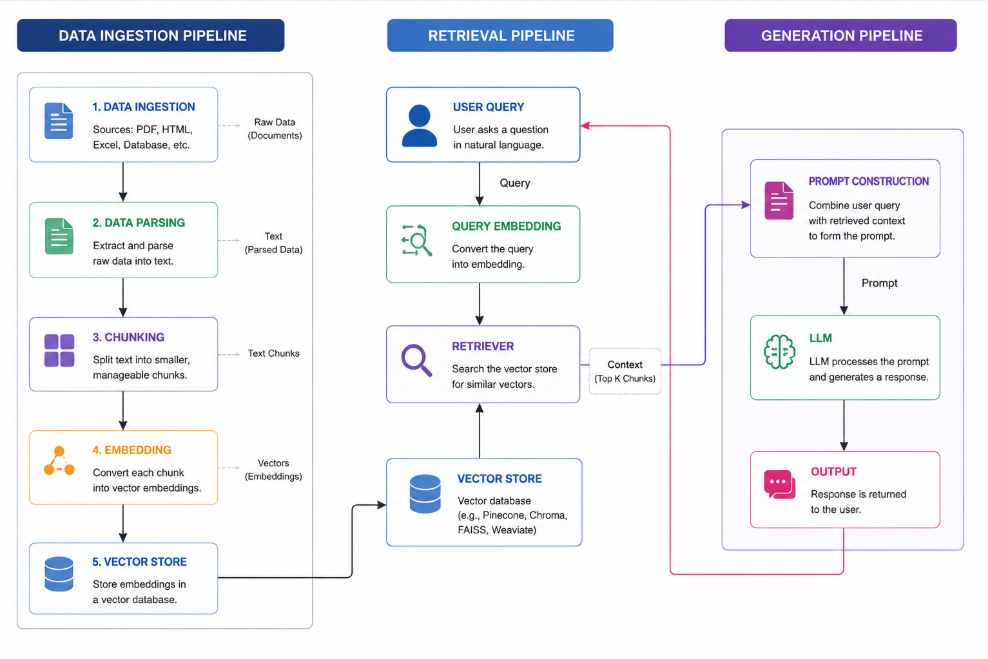


# Complete RAG Pipeline Architecture

The above is the end-to-end workflow of a Retrieval-Augmented Generation (RAG) system. The process is divided into three major stages:

1. Data Ingestion Pipeline
2. Retrieval Pipeline
3. Generation Pipeline

---

# 1. Data Ingestion Pipeline

The purpose of this stage is to prepare external data so that it can be efficiently searched and retrieved later.

## Step 1: Data Ingestion

The system collects data from various sources such as:

* PDF files
* HTML pages
* Excel sheets
* Databases

These documents become the knowledge source for the application.

## Step 2: Data Parsing

The ingested data is processed and converted into plain text.

Examples:

* Extract text from PDFs
* Parse HTML content
* Read database records
* Remove unnecessary formatting

Output:

```text
Raw Data → Parsed Text
```

## Step 3: Chunking

Large documents are split into smaller chunks.

Example:

```text
Document:
Company Leave Policy

↓

Chunk 1: Annual Leave
Chunk 2: Sick Leave
Chunk 3: Casual Leave
```

Chunking improves retrieval accuracy and helps stay within LLM context limits.

## Step 4: Embedding

Each chunk is converted into a vector representation using an embedding model.

```text
Text → Embedding Vector
```

These vectors capture the semantic meaning of the text.

## Step 5: Vector Store

The generated embeddings are stored in a vector database.

Common options include:

* Pinecone
* Chroma
* FAISS
* Weaviate
* Qdrant

The vector store serves as the knowledge base of the RAG system.

---

# 2. Retrieval Pipeline

This stage begins when a user submits a query.

## Step 1: User Query

Example:

```text
What is the leave policy?
```

## Step 2: Query Embedding

The query is converted into an embedding using the same embedding model.

```text
User Query → Query Vector
```

## Step 3: Retriever

The retriever performs similarity search against the vector store.

It identifies the most relevant chunks based on semantic similarity.

Example:

```text
Retrieved Chunks:

- Annual Leave Policy
- Sick Leave Policy
```

These retrieved chunks become the context for the LLM.

---

# 3. Generation Pipeline

The generation stage combines the user query with the retrieved context.

## Step 1: Prompt Construction

The final prompt sent to the LLM consists of:

* User Question
* Retrieved Context

Example:

```text
Question:
What is the leave policy?

Context:
Employees receive 20 annual leaves per year.
```

## Step 2: LLM Processing

The LLM uses the provided context to generate an answer grounded in the retrieved information.

## Step 3: Output

Example:

```text
Employees are entitled to 20 annual leaves per year,
along with sick and casual leave benefits.
```

---

# Complete Flow

```text
Documents
    ↓
Data Parsing
    ↓
Chunking
    ↓
Embeddings
    ↓
Vector Store
    ↓

User Query
    ↓
Query Embedding
    ↓
Retriever
    ↓
Relevant Context
    ↓

Context + User Prompt
    ↓
LLM
    ↓
Generated Response
```

---

# Why Use RAG?

Without RAG:

```text
Question → LLM → Answer
```

The model relies only on its training data.

With RAG:

```text
Question
    ↓
Retrieve Relevant Context
    ↓
Context + Prompt
    ↓
LLM
    ↓
Answer
```

This enables the model to answer using your organization's documents, making responses more accurate, up-to-date, and reliable.

## Key Benefits

* Improved accuracy
* Reduced hallucinations
* Access to private knowledge bases
* Up-to-date information retrieval
* Better enterprise search and question-answering


In [32]:
class RAGRetriever:
    """Handles query-based retrieval from the vector store"""
    
    def __init__(self, vector_store: VectorStore, embedding_manager: EmbeddingManager):
        """
        Initialize the retriever
        
        Args:
            vector_store: Vector store containing document embeddings
            embedding_manager: Manager for generating query embeddings
        """
        self.vector_store = vector_store
        self.embedding_manager = embedding_manager
    def retrieve(self, query: str, top_k: int = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]:
        """
        Retrieve relevant documents for a query
        
        Args:
            query: The search query
            top_k: Number of top results to return
            score_threshold: Minimum similarity score threshold
            
        Returns:
            List of dictionaries containing retrieved documents and metadata
        """
        print(f"Retrieving documents for query: '{query}'")
        print(f"Top K: {top_k}, Score threshold: {score_threshold}")
        
        # Generating query embedding(Converting to embeddings)
        query_embedding = self.embedding_manager.generate_embeddings([query])[0]
        
        # Search in vector store
        try:
            results = self.vector_store.collection.query(
                query_embeddings=[query_embedding.tolist()],
                n_results=top_k
            )
            
            # Process results
            retrieved_docs = []
            
            if results['documents'] and results['documents'][0]:
                documents = results['documents'][0]
                metadatas = results['metadatas'][0]
                distances = results['distances'][0]
                ids = results['ids'][0]
                
                for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)):
                    # Convert distance to similarity score (ChromaDB uses cosine distance)
                    similarity_score = 1 - distance
                    
                    if similarity_score >= score_threshold:
                        retrieved_docs.append({
                            'id': doc_id,
                            'content': document,
                            'metadata': metadata,
                            'similarity_score': similarity_score,
                            'distance': distance,
                            'rank': i + 1
                        })
                
                print(f"Retrieved {len(retrieved_docs)} documents (after filtering)")
            else:
                print("No documents found")
            
            return retrieved_docs
            
        except Exception as e:
            print(f"Error during retrieval: {e}")
            return []

rag_retriever=RAGRetriever(vectorstore,embedding_manager)

In [33]:
rag_retriever

In [ ]:
rag_retriever.retrieve("Hello My name is Aryan") # testing without match

Retrieving documents for query: 'Hello My name is Aryan'
Top K: 5, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 12.87it/s]

Generated embeddings with shape: (1, 384)
Retrieved 0 documents (after filtering)


[]

In [ ]:
rag_retriever.retrieve("prose narrative ") #testing with match in document

Retrieving documents for query: 'prose narrative '
Top K: 5, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 24.98it/s]

Generated embeddings with shape: (1, 384)
Retrieved 5 documents (after filtering)


[{'id': 'doc_be2ff586_37',
  'content': 'these devices are legitimate but none of them contravene\nour thesis: the basis of a novel is a story and a story is a\nnarrative of events in time sequence.\nFrom Aspects of the Novel : A Note\nThese are some lectures (the Clark Lectures) which were\ndelivered under the auspices of Trinity College, Cambridge,\nin the spring of 1927. They were informal, indeed talkative,\nin their tone and it seemed safer when presenting them in\nbook form not to mitigate the talk, in case nothing should\nbe left at all. Words such as ‘I’, ‘you’ ‘one’, ‘we’, ‘curiously\nenough’, ‘so to speak’, ‘only imagine’ and ‘of course’ will\nconsequently occur on every page and will rightly distress\nReprint 2026-27',
  'metadata': {'total_pages': 6,
   'creator': 'PageMaker 7.0',
   'title': 'Essay-06 (The story).pmd',
   'creationdate': '2017-12-21T15:23:33+00:00',
   'file_type': 'pdf',
   'author': 'Administrator',
   'page': 3,
   'moddate': '2026-03-28T11:31:26+05:30'

### Query Retrieval Pipeline + LLM (Integration of VectorDB Context Pipeline with LLM Output)


#  Workflow

Retrieval-Augmented Generation (RAG) enhances the capabilities of Large Language Models by providing them with relevant external information at inference time.

The process begins when a user submits a query. Instead of sending the query directly to the LLM, the query is first converted into an embedding (a numerical representation of the text). This embedding is then used to search a vector database containing embeddings of previously indexed documents.

The vector database retrieves the most semantically relevant information, which is referred to as the **context**. This retrieved context is combined with the user's original prompt and passed to the Large Language Model (LLM).

The LLM then generates a response using both the user's query and the retrieved contextual information, resulting in answers that are more accurate, grounded, and up-to-date.

## Workflow

```text
User Query
      ↓
Convert Query to Embedding
      ↓
Search Vector Database
      ↓
Retrieve Relevant Context
      ↓
Combine Context + User Prompt
      ↓
Large Language Model (LLM)
      ↓
Generated Response
```

## Why RAG?

Traditional LLMs rely solely on their training data, which can lead to outdated or hallucinated responses. RAG addresses this limitation by allowing the model to access external knowledge sources during inference.

### Benefits of RAG

* Improves response accuracy
* Reduces hallucinations
* Enables access to private knowledge bases
* Supports real-time and up-to-date information
* Enhances enterprise search and question-answering systems


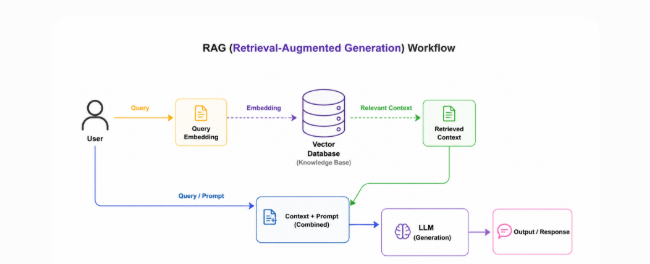

In [ ]:
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.3-70b-versatile") ##Importing llama 3.3-70b versatile model

In [43]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000025CBC084150>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000025CBC07B850>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [44]:
from langchain_core import retrievers
## RAG function: retrieve context + generate response
def rag_func(query,retriever,llm,top_k=3):
    ##retrieve the context
    results=retriever.retrieve(query,top_k=top_k)
    context="\n\n".join([doc['content'] for doc in results]) if results else ""
    if not context:
        return "No relevant context found!"
    
    #Generating the answer using LLM
    prompt=f"""Use the following context to answer the question concisely.
        Context:
        {context}

        Question: {query}

        Answer:"""
    
    response=llm.invoke([prompt.format(context=context,query=query)])
    return response.content

In [45]:
answer=rag_func("What is use of Novel?",rag_retriever,llm)
print(answer)

Retrieving documents for query: 'What is use of Novel?'
Top K: 3, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 27.18it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (after filtering)


A novel reflects a double allegiance to 'the life in time' and 'the life by values', and it supports 'the finer growths' such as character development, plot, and themes, making it an organism that tells a story and explores human interests.


## Enhanced RAG Pipeline



In [46]:
def rag_advanced(query, retriever, llm, top_k=5, min_score=0.2, return_context=False):
    """
    RAG pipeline(advanced):
    - Returns answer, sources, confidence score, and optionally full context.
    """
    results = retriever.retrieve(query, top_k=top_k, score_threshold=min_score)
    if not results:
        return {'answer': 'No relevant context found.', 'sources': [], 'confidence': 0.0, 'context': ''}
    
    # Prepare context and sources
    context = "\n\n".join([doc['content'] for doc in results])
    sources = [{
        'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
        'page': doc['metadata'].get('page', 'unknown'),
        'score': doc['similarity_score'],
        'preview': doc['content'][:300] + '...'
    } for doc in results]
    confidence = max([doc['similarity_score'] for doc in results])
    
    # Generate answer
    prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {query}\n\nAnswer:"""
    response = llm.invoke([prompt.format(context=context, query=query)])
    
    output = {
        'answer': response.content,
        'sources': sources,
        'confidence': confidence
    }
    if return_context:
        output['context'] = context
    return output

# Example:
result = rag_advanced("What is Sell my Dreams chapter", rag_retriever, llm, top_k=3, min_score=0.1, return_context=True)
print("Answer:", result['answer'])
print("Sources:", result['sources'])
print("Confidence:", result['confidence'])
print("Context Preview:", result['context'][:300])

Retrieving documents for query: 'What is Sell my Dreams chapter'
Top K: 3, Score threshold: 0.1
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 49.57it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (after filtering)


Answer: There is no "Sell my Dreams" chapter in the given context. The context appears to be a language work exercise from a book called "KALEIDOSCOPE", with sections on vocabulary and grammar, but it does not mention a chapter called "Sell my Dreams".
Sources: [{'source': 'pdf1.pdf', 'page': 9, 'score': 0.1706559658050537, 'preview': '10/KALEIDOSCOPE\nLanguage Work\nA. Vocabulary\nLook up the meanings of the following phrases under ‘dream’\nand ‘sell’ in the dictionary\ndream         sell\ndream on sell-by date\ndream something away selling-point\n(not) dream of doing something sell-out\ndream something up selling price\nlook like a dream ...'}, {'source': 'pdf1.pdf', 'page': 9, 'score': 0.1706559658050537, 'preview': '10/KALEIDOSCOPE\nLanguage Work\nA. Vocabulary\nLook up the meanings of the following phrases under ‘dream’\nand ‘sell’ in the dictionary\ndream         sell\ndream on sell-by date\ndream something away selling-point\n(not) dream of doing something sell-out\ndream someth

In [53]:
# 2) Advanced RAG Pipeline: Streaming, Citations, History, Summarization ---
from typing import List, Dict, Any
import time

class AdvancedRAGPipeline:
    def __init__(self, retriever, llm):
        self.retriever = retriever
        self.llm = llm
        self.history = []  # Store query history

    def query(self, question: str, top_k: int = 5, min_score: float = 0.2, stream: bool = False, summarize: bool = False) -> Dict[str, Any]:
        # Retrieve relevant documents
        results = self.retriever.retrieve(question, top_k=top_k, score_threshold=min_score)
        if not results:
            answer = "No relevant context found."
            sources = []
            context = ""
        else:
            context = "\n\n".join([doc['content'] for doc in results])
            sources = [{
                'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
                'page': doc['metadata'].get('page', 'unknown'),
                'score': doc['similarity_score'],
                'preview': doc['content'][:120] + '...'
            } for doc in results]
            # Streaming answer simulation
            prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {question}\n\nAnswer:"""
            if stream:
                print("Streaming answer:")
                for i in range(0, len(prompt), 80):
                    print(prompt[i:i+80], end='', flush=True)
                    time.sleep(0.05)
                print()
            response = self.llm.invoke([prompt.format(context=context, question=question)])
            answer = response.content

        # Add citations to answer
        citations = [f"[{i+1}] {src['source']} (page {src['page']})" for i, src in enumerate(sources)]
        answer_with_citations = answer + "\n\nCitations:\n" + "\n".join(citations) if citations else answer

        # Optionally summarize answer
        summary = None
        if summarize and answer:
            summary_prompt = f"Summarize the following answer in 2 sentences:\n{answer}"
            summary_resp = self.llm.invoke([summary_prompt])
            summary = summary_resp.content

        # Store query history
        self.history.append({
            'question': question,
            'answer': answer,
            'sources': sources,
            'summary': summary
        })

        return {
            'question': question,
            'answer': answer_with_citations,
            'sources': sources,
            'summary': summary,
            'history': self.history
        }

# Example 2) :
adv_rag = AdvancedRAGPipeline(rag_retriever, llm)
result = adv_rag.query("Gabriel Garcia Marquez?", top_k=3, min_score=0.1, stream=True, summarize=True)
print("\nFinal Answer:", result['answer'])
print("Summary:", result['summary'])
print("History:", result['history'][-1])

Retrieving documents for query: 'Gabriel Garcia Marquez?'
Top K: 3, Score threshold: 0.1
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 70.39it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (after filtering)
Streaming answer:
Use the following context to answer the question concisely.
Context:
2/KALEIDOSCOPE
I S I SI S I SI Sell my Dreamsell my Dreamsell my Dreamsell my Dreamsell my Dreams
Gabriel Garcia Marquez was brought up by his
grandparents in Northern Columbia because his
parents were poor and struggling. A novelist, short-
story wri

ter and journalist, he is widely considered
the greatest living Latin American master of narrative.
Marquez won the Nobel Prize in Literature in 1982.
His two masterpieces ar e One Hundred Years in
Solitude (1967, tr. 1970) and Love in The Time of
Cholera (1985, tr. 1988). His themes are violence,
solitude and the overwhelming human need for love.
This story reflects, like most of his works, a high
point in Latin American magical realism; it is rich
and lucid, mixing reality with fantasy.
One morning at nine o’clock, while we were having breakfast
on the terrace of the Havana Riviera Hotel under a bright
sun, a huge wave picked up several cars that were driving
down the avenue along the seawall or parked on the

2/KALEIDOSCOPE
I S I SI S I SI Sell my Dreamsell my Dreamsell my Dreamsell my Dreamsell my Dreams
Gabriel Garcia Marquez was brought up by his
grandparents in Northern Columbia because his
parents were poor and struggling. A novelist, short-
story writer and journalist, he is w